In [42]:
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
import zipfile
import matplotlib.pyplot as plt

pd.set_option('display.width', 1000)

In [43]:
CITY = "Potsdam, Germany"
CORRIDOR_STREET_WIDTH = 10  # meters
SCHOOL_RADIUS = 500  # meters
JAHRE = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [44]:
def get_ufa(year: int) -> gpd.GeoDataFrame:
    with zipfile.ZipFile(f"../data/unfallatlas/Unfallorte{year}_EPSG25832_CSV.zip") as z:
        candidates = [n for n in z.namelist() if n.endswith(".txt") or n.endswith(".csv")]
        if not candidates:
            raise ValueError(f"No Unfallorte file found for year {year}")
        else:
            with z.open(candidates[0]) as f:
                df = pd.read_csv(f, sep=";", low_memory=False)
                df["XGCSWGS84"] = df["XGCSWGS84"].str.replace(",", ".")
                df["YGCSWGS84"] = df["YGCSWGS84"].str.replace(",", ".")
                df["XGCSWGS84"] = pd.to_numeric(df["XGCSWGS84"], errors="coerce")
                df["YGCSWGS84"] = pd.to_numeric(df["YGCSWGS84"], errors="coerce")
                gdf = gpd.GeoDataFrame(
                    df,
                    geometry=gpd.points_from_xy(df["XGCSWGS84"], df["YGCSWGS84"]),
                    crs="EPSG:4326",
                )
                gdf = gdf.to_crs("EPSG:25832")
                return gdf

In [45]:
def get_street_geometry_with_tempo(city: str, tempo: int) -> gpd.GeoDataFrame:
    tags = {"maxspeed": str(tempo)}
    gdf = ox.features_from_place(city, tags)
    gdf = gdf[gdf.geometry.type.isin(["LineString", "MultiLineString"])]
    gdf = gdf.to_crs("EPSG:25832")    
    return gdf

def get_schools(city: str) -> gpd.GeoDataFrame:
    tags = {"amenity": "school"}
    gdf = ox.features_from_place(city, tags)
    gdf = gdf[gdf.geometry.type == "Point"]
    gdf = gdf.to_crs("EPSG:25832")    
    return gdf

In [46]:
ufa = pd.concat([get_ufa(year) for year in JAHRE], ignore_index=True)
streets_tempo_30 = get_street_geometry_with_tempo(CITY, 30)
streets_tempo_50 = get_street_geometry_with_tempo(CITY, 50)
schools = get_schools(CITY)
print(ufa.columns)

Index(['FID', 'OBJECTID', 'ULAND', 'UREGBEZ', 'UKREIS', 'UGEMEINDE', 'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG', 'UKATEGORIE', 'UART', 'UTYP1', 'ULICHTVERH', 'IstStrasse', 'IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz', 'IstSonstig', 'LINREFX', 'LINREFY', 'XGCSWGS84', 'YGCSWGS84', 'geometry', 'UIDENTSTLA', 'LICHT', 'STRZUSTAND', 'OBJECTID_1', 'IstSonstige', 'UIDENTSTLAE', 'OID_', 'IstStrassenzustand', 'PLST'], dtype='object')


In [47]:
streets_tempo_50_buffered = streets_tempo_50.copy()
streets_tempo_50_buffered["geometry"] = streets_tempo_50_buffered.geometry.buffer(CORRIDOR_STREET_WIDTH)
ufa_on_tempo_50 = gpd.sjoin(
    ufa,
    streets_tempo_50_buffered,
    how="inner",
    predicate="intersects",
)
print(ufa_on_tempo_50.head())

        FID  OBJECTID  ULAND  UREGBEZ  UKREIS  UGEMEINDE  UJAHR  UMONAT  USTUNDE  UWOCHENTAG  ...  covered  parking:lane:left  parking:condition:left:default  parking:condition:left:maxstay  parking:condition:left:time_interval  tree_lined  parking:both:restriction:conditional  winter_service  check_date:sidewalk:surface  sidewalk:right:smoothness
261591  NaN  109919.0     12        0      54          0   2017       1       19           2  ...      NaN                NaN                             NaN                             NaN                                   NaN         NaN                                   NaN             NaN                          NaN                        NaN
261711  NaN  110039.0     12        0      54          0   2017       1        2           4  ...      NaN                NaN                             NaN                             NaN                                   NaN         NaN                                   NaN             NaN       

In [61]:
# schools near tempo 50 streets
schools_buffered = schools.copy()
schools_buffered["geometry"] = schools_buffered.geometry.buffer(250)
schools_near_t50 = gpd.sjoin(
    streets_tempo_50,
    schools_buffered,
    how="inner",
    predicate="intersects",
)
print(schools_near_t50.head(), schools_near_t50.shape)

                                                                geometry maxspeed traffic_sign direction      highway man_made mapillary colour height mast:type  ... fixme grades addr:housename name:1956-1991 operator:short name:1951-1974 name:1974-1991 old_name:etymology:wikidata_right landuse contact:facebook
element_left id_left                                                                                                                                              ...                                                                                                                                                   
way          4593099   LINESTRING (776084.523 5812981.364, 776085.526...       50          NaN       NaN     tertiary      NaN       NaN    NaN    NaN       NaN  ...   NaN    NaN            NaN            NaN            NaN            NaN            NaN                               NaN     NaN              NaN
             4593102   LINESTRING (775752.07 5814207.437, 775

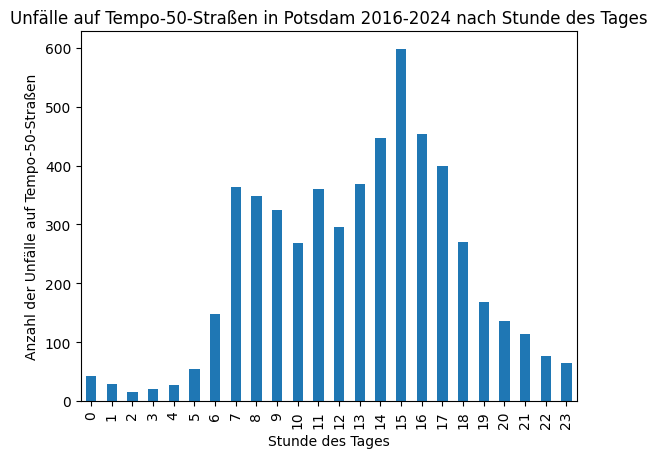

In [48]:
# make a histogram of accident counts by hour of day
ufa_on_tempo_50["UHRZEIT"] = pd.to_numeric(ufa_on_tempo_50["USTUNDE"], errors="coerce")
hist = ufa_on_tempo_50["UHRZEIT"].value_counts().sort_index()

fig, ax = plt.subplots()
hist.plot(kind="bar", ax=ax)
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("Anzahl der Unfälle auf Tempo-50-Straßen")
ax.set_title(f"Unfälle auf Tempo-50-Straßen in Potsdam {min(JAHRE)}-{max(JAHRE)} nach Stunde des Tages")
plt.show()

In [ ]:
schools_buffered = schools.copy()
schools_buffered["geometry"] = schools_buffered.geometry.buffer(SCHOOL_RADIUS)
schools_near_t50 = gpd.sjoin(
    ufa,
    schools_buffered,
    how="inner",
    predicate="intersects",
)
print(schools_near_t50.head())

        FID  OBJECTID  ULAND  UREGBEZ  UKREIS  UGEMEINDE  UJAHR  UMONAT  USTUNDE  UWOCHENTAG  ...  fixme  grades  addr:housename  name:1956-1991  operator:short  name:1951-1974  name:1974-1991  old_name:etymology:wikidata  landuse  contact:facebook
261870  NaN  110198.0     12        0      54          0   2017       3        8           3  ...    NaN     NaN             NaN             NaN             NaN             NaN             NaN                          NaN      NaN               NaN
261939  NaN  110267.0     12        0      54          0   2017       2        7           5  ...    NaN     NaN             NaN             NaN             NaN             NaN             NaN                          NaN      NaN               NaN
262556  NaN  110884.0     12        0      54          0   2017       4       16           6  ...    NaN     NaN             NaN             NaN             NaN             NaN             NaN                          NaN      NaN               NaN
2626

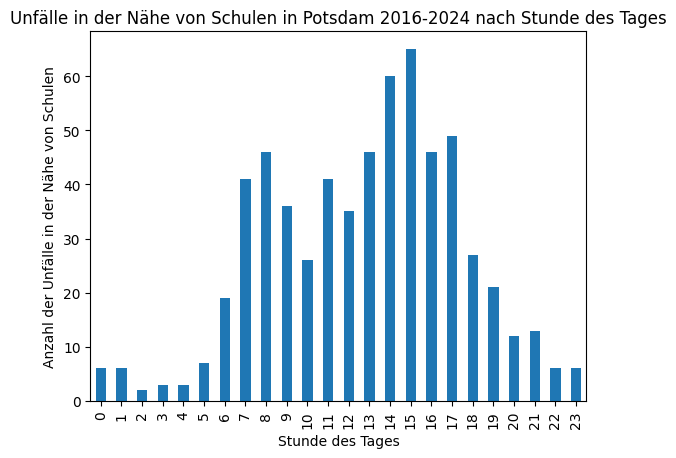

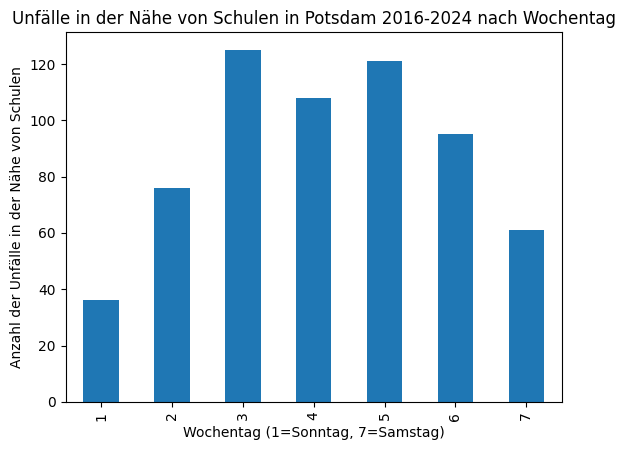

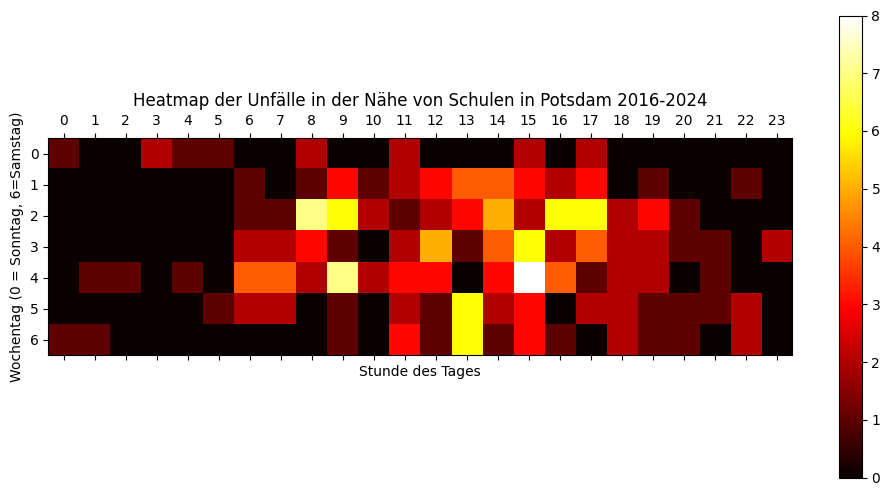

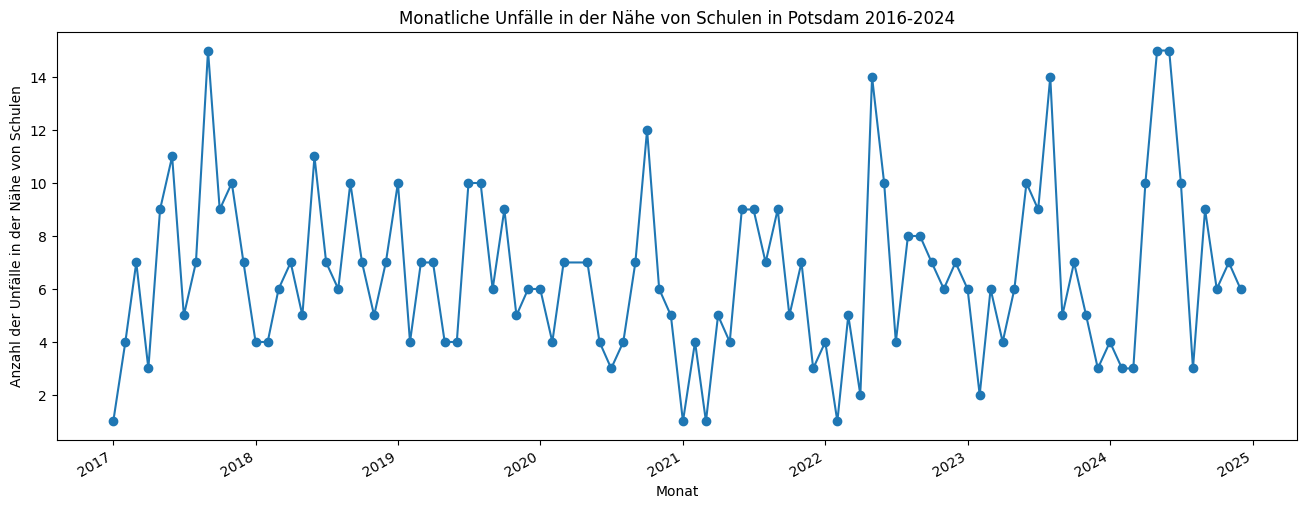

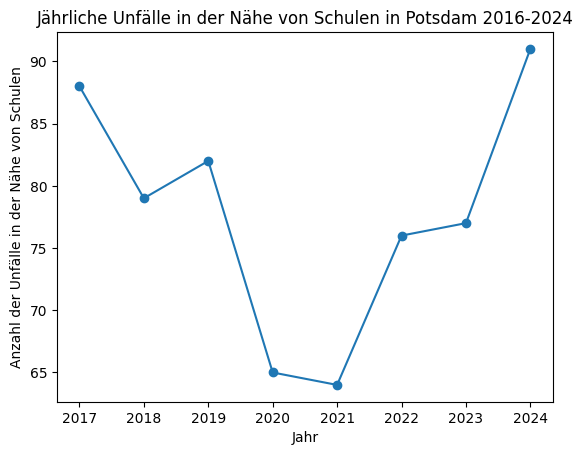

In [ ]:
schools_near_t50["UHRZEIT"] = pd.to_numeric(schools_near_t50["USTUNDE"], errors="coerce")
hist_schools = schools_near_t50["UHRZEIT"].value_counts().sort_index()
fig, ax = plt.subplots()
hist_schools.plot(kind="bar", ax=ax)
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("Anzahl der Unfälle in der Nähe von Schulen")
ax.set_title(f"Unfälle in der Nähe von Schulen in Potsdam {min(JAHRE)}-{max(JAHRE)} nach Stunde des Tages")
plt.show()

# histogram nach UWOCHENTAG
schools_near_t50["UWOCHENTAG"] = pd.to_numeric(schools_near_t50["UWOCHENTAG"], errors="coerce")
hist_day = schools_near_t50["UWOCHENTAG"].value_counts().sort_index()
fig, ax = plt.subplots()
hist_day.plot(kind="bar", ax=ax)
ax.set_xlabel("Wochentag (1=Sonntag, 7=Samstag)")
ax.set_ylabel("Anzahl der Unfälle in der Nähe von Schulen")
ax.set_title(f"Unfälle in der Nähe von Schulen in Potsdam {min(JAHRE)}-{max(JAHRE)} nach Wochentag")
plt.show()

# heatmap of accidents with x axis hour of day and y axis day of week
heatmap_data = schools_near_t50.pivot_table(
    index="UWOCHENTAG",
    columns="UHRZEIT",
    values="OID_",
    aggfunc="count",
    fill_value=0,
)
fig, ax = plt.subplots(figsize=(12, 6))
cax = ax.matshow(heatmap_data, cmap="hot")
fig.colorbar(cax)
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("Wochentag (0 = Sonntag, 6=Samstag)")
ax.set_title(f"Heatmap der Unfälle in der Nähe von Schulen in Potsdam {min(JAHRE)}-{max(JAHRE)}")
ax.set_xticks(range(0, 24))
ax.set_yticks(range(0, 7))
plt.show()

# scatter/line plot of accidents by year-month
schools_near_t50["DATE"] = pd.to_datetime(schools_near_t50["UJAHR"].astype(str) + "-" + schools_near_t50["UMONAT"].astype(str).str.zfill(2))
ufa_by_month = schools_near_t50.groupby(schools_near_t50["DATE"].dt.to_period("M")).size()
ufa_by_month.index = ufa_by_month.index.to_timestamp()
fig, ax = plt.subplots(figsize=(16, 6))
ufa_by_month.plot(ax=ax, marker="o")
ax.set_xlabel("Monat")
ax.set_ylabel("Anzahl der Unfälle in der Nähe von Schulen")
ax.set_title(f"Monatliche Unfälle in der Nähe von Schulen in Potsdam {min(JAHRE)}-{max(JAHRE)}")
plt.show()

ufa_by_year = schools_near_t50.groupby("UJAHR").size()
fig, ax = plt.subplots()
ufa_by_year.plot(ax=ax, marker="o")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl der Unfälle in der Nähe von Schulen")
ax.set_title(f"Jährliche Unfälle in der Nähe von Schulen in Potsdam {min(JAHRE)}-{max(JAHRE)}")
plt.show()

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

ufa_not_schools = ufa[~ufa.index.isin(schools_near_t50.index)].copy()
ufa_not_schools["WEEKEND"] = ufa_not_schools["UWOCHENTAG"].isin([0, 7])
schools_near_t50["WEEKEND"] = schools_near_t50["UWOCHENTAG"].isin([0, 7])

contingency = pd.DataFrame({
    "Schools": [
        schools_near_t50['WEEKEND'].sum(),            
        (~schools_near_t50['WEEKEND']).sum()          
    ],
    "Other": [
        ufa_not_schools['WEEKEND'].sum(),
        (~ufa_not_schools['WEEKEND']).sum()
    ]
}, index=["Weekend", "Weekday"])
chi2, p, dof, expected = chi2_contingency(contingency, correction=False)
if p < 0.1:
    print(f"Chi2-Test Weekend vs Weekday Schools vs Other")
    print(f"Das Auftreten von Unfällen an Wochentagen und Wochenende unterscheidet sich signifikant zwischen Schulen und anderen Orten (p={p:.4f})")
else:
    print(f"Kein signifikanter Unterschied im Auftreten von Unfällen an Wochentagen und Wochenende zwischen Schulen und anderen Orten (p={p:.4f})")

count = np.array([
    (~schools_near_t50['WEEKEND']).sum(), 
    (~ufa_not_schools['WEEKEND']).sum()
])
nobs = np.array([
    len(schools_near_t50), 
    len(ufa_not_schools)
])
stat, p_z = proportions_ztest(count, nobs, alternative='larger')

if p_z < 0.1:
    print("\nZ-Test Weekday proportion Schools > Other")
    print("Z-Statistik:", stat, "p-Wert:", p_z)
    print(f"Der Anteil der Unfälle an Wochentagen ist signifikant größer in der Nähe von Schulen als anderswo (p={p_z:.4f})")
else:
    print(f"\nKein signifikanter Unterschied im Anteil der Unfälle an Wochentagen zwischen Schulen und anderen Orten (p={p_z:.4f})")


ufa_not_schools["SCHOOLZEIT"] = (ufa_not_schools["USTUNDE"].between(7, 9) | ufa_not_schools["USTUNDE"].between(15, 17)) & (~ufa_not_schools["WEEKEND"])
schools_near_t50["SCHOOLZEIT"] = (schools_near_t50["USTUNDE"].between(7, 9) | schools_near_t50["USTUNDE"].between(15, 17)) & (~schools_near_t50["WEEKEND"])
contingency_schooltime = pd.DataFrame({
    "Schools": [
        schools_near_t50['SCHOOLZEIT'].sum(),            
        (~schools_near_t50['SCHOOLZEIT']).sum()          
    ],
    "Other": [
        ufa_not_schools['SCHOOLZEIT'].sum(),
        (~ufa_not_schools['SCHOOLZEIT']).sum()
    ]
}, index=["School Time", "Other Time"])
chi2, p, dof, expected = chi2_contingency(contingency_schooltime, correction=False)
if p < 0.1:
    print("\nChi2-Test School Time vs Other Time Schools vs Other")
    print(f"Das Auftreten von Unfällen zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) unterscheidet sich signifikant zwischen Schulen und anderen Orten (p={p:.4f})")
else:
    print(f"Kein signifikanter Unterschied im Auftreten von Unfällen zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) zwischen Schulen und anderen Orten (p={p:.4f})")

count_schooltime = np.array([
    schools_near_t50['SCHOOLZEIT'].sum(), 
    ufa_not_schools['SCHOOLZEIT'].sum()
])
nobs_schooltime = np.array([
    len(schools_near_t50), 
    len(ufa_not_schools)
])
stat_schooltime, p_z_schooltime = proportions_ztest(count_schooltime, nobs_schooltime, alternative='larger')
if p_z_schooltime < 0.1:
    print("\nZ-Test School Time proportion Schools > Other")
    print("Z-Statistik:", stat_schooltime, "p-Wert:", p_z_schooltime)
    print(f"Der Anteil der Unfälle zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) ist signifikant größer in der Nähe von Schulen als anderswo (p={p_z_schooltime:.4f})")
else:
    print(f"\nKein signifikanter Unterschied im Anteil der Unfälle zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) zwischen Schulen und anderen Orten (p={p_z_schooltime:.4f})")

Chi2-Test Weekend vs Weekday Schools vs Other
Das Auftreten von Unfällen an Wochentagen und Wochenende unterscheidet sich signifikant zwischen Schulen und anderen Orten (p=0.0785)

Z-Test Weekday proportion Schools > Other
Z-Statistik: 1.7593001495281615 p-Wert: 0.03926327061405548
Der Anteil der Unfälle an Wochentagen ist signifikant größer in der Nähe von Schulen als anderswo (p=0.0393)

Chi2-Test School Time vs Other Time Schools vs Other
Das Auftreten von Unfällen zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) unterscheidet sich signifikant zwischen Schulen und anderen Orten (p=0.0004)

Z-Test School Time proportion Schools > Other
Z-Statistik: 3.5746308819924195 p-Wert: 0.00017536116852097348
Der Anteil der Unfälle zur Schulzeit (7-9 Uhr und 15-17 Uhr an Wochentagen) ist signifikant größer in der Nähe von Schulen als anderswo (p=0.0002)
